# Exercises, Chapter 13, "Logistic Regression"

In [2]:
import dataclasses
import os
import sys
import typing

import arviz
import bambi
import numpy
import pandas

from matplotlib import pyplot
from scipy import special
from scipy import stats

sys.path.append(os.path.abspath("/home/bgawalt/ros"))
import bg_ros

/home/bgawalt/venv/ros/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


## 13.1, Fitting logistic regression to data

> The
> [folder NES contains](https://github.com/avehtari/ROS-Examples/tree/master/NES/)
> the survey data of presidential preference and income for the 1992 election
> analyzed in Section 13.1, along with other variables including sex, ethnicity,
> education, party identification, and political ideology.
>
> (a) Fit a logistic regression predicting support for Bush given all these
>     inputs. Consider how to include these as regression predictors and also
>     consider possible interactions.
>
> (b) Evaluate and compare the different models you have fit.
>
> (c) For your chosen model, discuss and compare the importance of each input
>     variable in the prediction.

In [2]:
nes_parser = bg_ros.DATFileParser('/home/bgawalt/ros/datasets/nes.txt')
nes_parser.add_int_filter('year', lambda y: y == 1992)
nes_df, nes_nas = nes_parser.parse(
    ["year", "income", "age", "gender", "race", "real_ideo", "rvote"],
    [],
)
nes_df.describe()
for k, v in nes_nas.items():
    print(k, v)

rvote 250
real_ideo 373


In [3]:
nes_df.describe()

,year,income,age,gender,race,real_ideo,rvote
count,1101.0,1101.000000,1101.000000,1101.000000,1101.000000,1101.000000,1101.00000
mean,1992.0,3.202543,46.294278,1.508629,1.329700,4.188011,0.37148
std,0.0,1.049603,16.786376,0.500153,0.887959,1.449163,0.48342
min,1992.0,1.000000,18.000000,1.000000,1.000000,1.000000,0.00000
25%,1992.0,3.000000,33.000000,1.000000,1.000000,3.000000,0.00000
50%,1992.0,3.000000,43.000000,2.000000,1.000000,4.000000,0.00000
75%,1992.0,4.000000,58.000000,2.000000,1.000000,5.000000,1.00000
max,1992.0,5.000000,91.000000,2.000000,5.000000,7.000000,1.00000


In [4]:
print(sorted(set(nes_df['race'])))

[1, 2, 3, 4, 5]


In [5]:
print(bg_ros.dataframe_describe_markdown(nes_df))

|         | year | income | age | gender | race | real_ideo | rvote
--------- | ---- | ------ | --- | ------ | ---- | --------- | -----
**count** | 1101.00 | 1101.00 | 1101.00 | 1101.00 | 1101.00 | 1101.00 | 1101.00
**mean**  | 1992.00 | 3.20 | 46.29 | 1.51 | 1.33 | 4.19 | 0.37
**std**   | 0.00 | 1.05 | 16.79 | 0.50 | 0.89 | 1.45 | 0.48
**min**   | 1992.00 | 1.00 | 18.00 | 1.00 | 1.00 | 1.00 | 0.00
**25%**   | 1992.00 | 3.00 | 33.00 | 1.00 | 1.00 | 3.00 | 0.00
**50%**   | 1992.00 | 3.00 | 43.00 | 2.00 | 1.00 | 4.00 | 0.00
**75%**   | 1992.00 | 4.00 | 58.00 | 2.00 | 1.00 | 5.00 | 1.00
**max**   | 1992.00 | 5.00 | 91.00 | 2.00 | 5.00 | 7.00 | 1.00



In [60]:
model1_income_linear = bambi.Model("rvote['1'] ~ income", nes_df, family='bernoulli')
model1_fit = model1_income_linear.fit(idata_kwargs={"log_likelihood": True})
arviz.summary(model1_fit)
print(bg_ros.bambi_markdown(model1_fit, ['income',]))

Modeling the probability that rvote==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, income]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | nan | nan
Intercept | -1.31 | 0.21
income    | 0.24 | 0.06



In [61]:
model2_income_cat = bambi.Model("rvote['1'] ~ C(income)", nes_df, family='bernoulli')
model2_fit = model2_income_cat.fit(idata_kwargs={"log_likelihood": True})    

Modeling the probability that rvote==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, C(income)]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


In [62]:
print(
    bg_ros.bambi_markdown(
        model2_fit,
        [f'C(income)[{i}]' for i in range(2, 6)],
    )
)

Coef.        | Mean   | s.e.
------------ | ------ | ------
sigma        | nan | nan
Intercept    | -1.16 | 0.22
C(income)[2] | 0.40 | 0.27
C(income)[3] | 0.64 | 0.24
C(income)[4] | 0.76 | 0.23
C(income)[5] | 0.99 | 0.31



<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

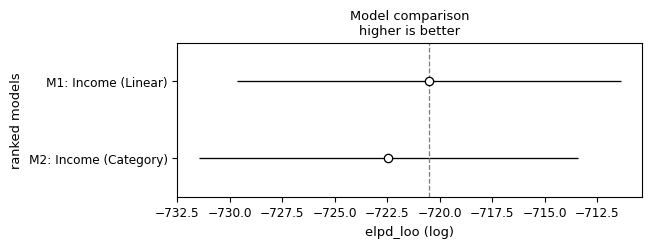

In [63]:
nes_models = {
    'M1: Income (Linear)': model1_fit,
    'M2: Income (Category)': model2_fit,
}
nes_compare = arviz.compare(nes_models)
arviz.plot_compare(nes_compare)

In [64]:
mu = numpy.mean(nes_df['age'])
sig = numpy.std(nes_df['age'])
nes_df['age_z'] = (nes_df['age'] - mu) / sig
nes_df.describe()

,year,income,age,gender,race,real_ideo,rvote,age_z
count,1101.0,1101.000000,1101.000000,1101.000000,1101.000000,1101.000000,1101.00000,1.101000e+03
mean,1992.0,3.202543,46.294278,1.508629,1.329700,4.188011,0.37148,-6.453612e-18
std,0.0,1.049603,16.786376,0.500153,0.887959,1.449163,0.48342,1.000454e+00
min,1992.0,1.000000,18.000000,1.000000,1.000000,1.000000,0.00000,-1.686316e+00
25%,1992.0,3.000000,33.000000,1.000000,1.000000,3.000000,0.00000,-7.923282e-01
50%,1992.0,3.000000,43.000000,2.000000,1.000000,4.000000,0.00000,-1.963363e-01
75%,1992.0,4.000000,58.000000,2.000000,1.000000,5.000000,1.00000,6.976516e-01
max,1992.0,5.000000,91.000000,2.000000,5.000000,7.000000,1.00000,2.664425e+00


In [65]:
model3_income_age_gender = bambi.Model("rvote['1'] ~ income + age_z + gender", nes_df, family='bernoulli')
model3_fit = model3_income_age_gender.fit(idata_kwargs={"log_likelihood": True})
print(
    bg_ros.bambi_markdown(
        model3_fit,
        ['income', 'age_z', 'gender'],
    )
)

Modeling the probability that rvote==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, income, age_z, gender]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | nan | nan
Intercept | -1.25 | 0.30
income    | 0.25 | 0.06
age_z     | 0.10 | 0.06
gender    | -0.06 | 0.12



<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

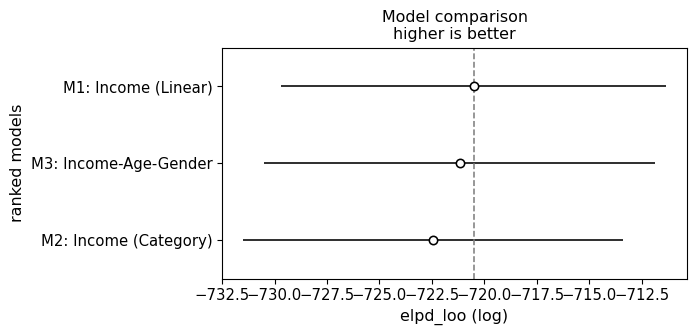

In [66]:
nes_models['M3: Income-Age-Gender'] = model3_fit
nes_compare = arviz.compare(nes_models)
arviz.plot_compare(nes_compare)

In [67]:
model4_age_x_gender = bambi.Model("rvote['1'] ~ income + age_z + gender + age_z:gender", nes_df, family='bernoulli')
model4_fit = model4_age_x_gender.fit(idata_kwargs={"log_likelihood": True})
print(
    bg_ros.bambi_markdown(
        model4_fit,
        ['income', 'age_z', 'gender', 'age_z:gender'],
    )
)

Modeling the probability that rvote==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, income, age_z, gender, age_z:gender]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


Coef.        | Mean   | s.e.
------------ | ------ | ------
sigma        | nan | nan
Intercept    | -1.28 | 0.31
income       | 0.26 | 0.06
age_z        | -0.12 | 0.20
gender       | -0.06 | 0.13
age_z:gender | 0.14 | 0.12



<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

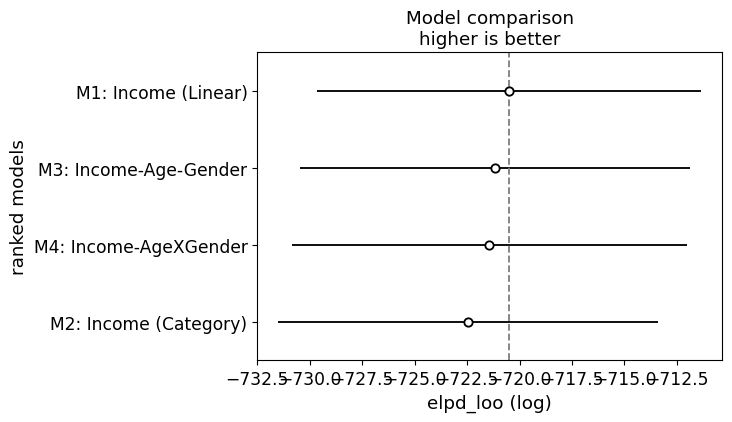

In [68]:
nes_models['M4: Income-AgeXGender'] = model4_fit
nes_compare = arviz.compare(nes_models)
arviz.plot_compare(nes_compare)

In [69]:
model5_iagr = bambi.Model(
    "rvote['1'] ~ income + age_z + gender + C(race)",
    nes_df,
    family='bernoulli'
)
model5_fit = model5_iagr.fit(idata_kwargs={"log_likelihood": True})
print(
    bg_ros.bambi_markdown(
        model5_fit,
        (
            ['income', 'age_z', 'gender'] + 
            [f'C(race)[{i}]' for i in range(2, 6)]
        ),
    )
)

Modeling the probability that rvote==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, income, age_z, gender, C(race)]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


Coef.      | Mean   | s.e.
---------- | ------ | ------
sigma      | nan | nan
Intercept  | -1.03 | 0.31
income     | 0.21 | 0.07
age_z      | 0.07 | 0.07
gender     | -0.02 | 0.13
C(race)[2] | -2.35 | 0.39
C(race)[3] | 0.37 | 0.48
C(race)[4] | -0.11 | 0.38
C(race)[5] | 0.07 | 0.33



<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

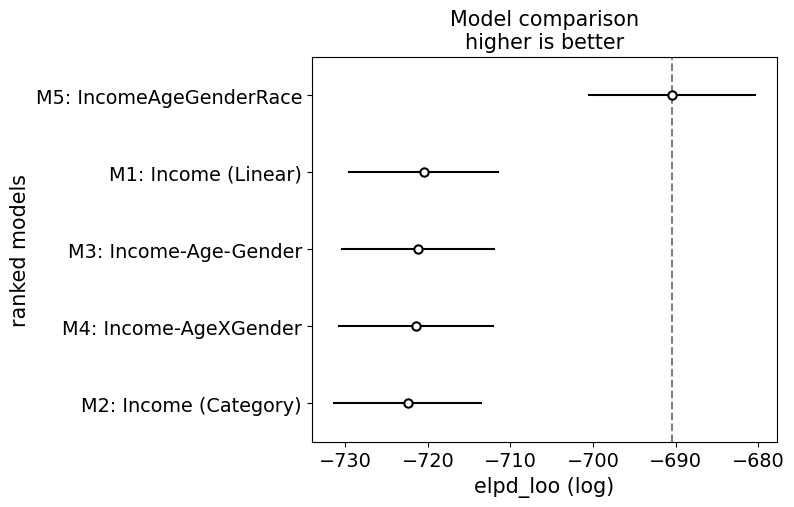

In [70]:
nes_models['M5: IncomeAgeGenderRace'] = model5_fit
nes_compare = arviz.compare(nes_models)
arviz.plot_compare(nes_compare)

In [71]:
model6_inc_x_race = bambi.Model(
    "rvote['1'] ~ income + C(race) + income:C(race)",
    nes_df,
    family='bernoulli'
)
model6_fit = model6_inc_x_race.fit(idata_kwargs={"log_likelihood": True})
print(
    bg_ros.bambi_markdown(
        model6_fit,
        (
            ['income',] + 
            [f'C(race)[{i}]' for i in range(2, 6)] +
            [f'income:C(race)[{i}]' for i in range(2, 6)]
        ),
    )
)

Modeling the probability that rvote==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, income, C(race), income:C(race)]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


Coef.             | Mean   | s.e.
----------------- | ------ | ------
sigma             | nan | nan
Intercept         | -1.05 | 0.22
income            | 0.20 | 0.06
C(race)[2]        | -1.25 | 0.71
C(race)[3]        | -0.02 | 0.89
C(race)[4]        | -0.84 | 0.84
C(race)[5]        | -0.21 | 0.71
income:C(race)[2] | -0.51 | 0.29
income:C(race)[3] | 0.14 | 0.27
income:C(race)[4] | 0.26 | 0.27
income:C(race)[5] | 0.09 | 0.25



<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

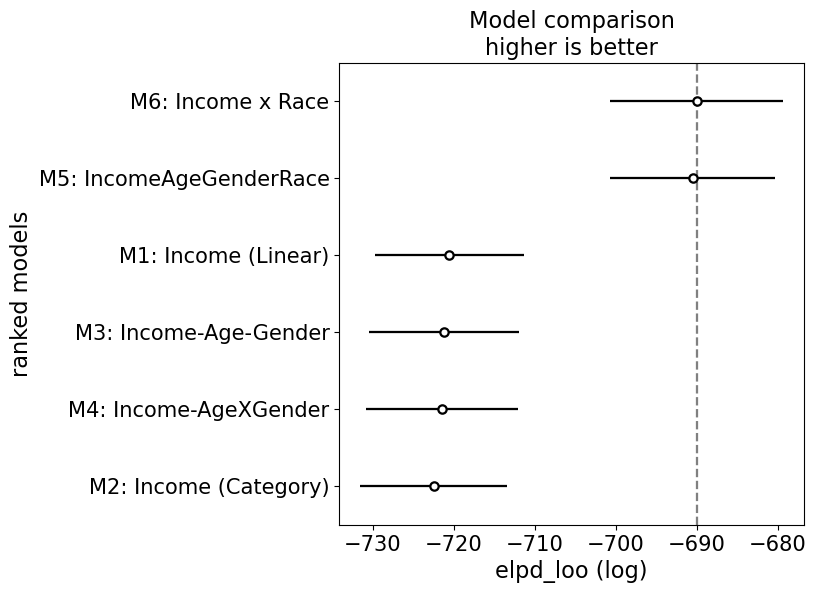

In [72]:
nes_models['M6: Income x Race'] = model6_fit
nes_compare = arviz.compare(nes_models)
arviz.plot_compare(nes_compare)

In [73]:
model7_iagr_ideo = bambi.Model(
    "rvote['1'] ~ income + age_z + gender + C(race) + real_ideo",
    nes_df,
    family='bernoulli'
)
model7_fit = model7_iagr_ideo.fit(idata_kwargs={"log_likelihood": True})
print(
    bg_ros.bambi_markdown(
        model7_fit,
        (
            ['income', 'age_z', 'gender'] + 
            [f'C(race)[{i}]' for i in range(2, 6)] +
            ['real_ideo',]
        ),
    )
)

Modeling the probability that rvote==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, income, age_z, gender, C(race), real_ideo]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


Coef.      | Mean   | s.e.
---------- | ------ | ------
sigma      | nan | nan
Intercept  | -5.21 | 0.47
income     | 0.17 | 0.07
age_z      | -0.04 | 0.08
gender     | 0.18 | 0.15
C(race)[2] | -2.43 | 0.40
C(race)[3] | 0.49 | 0.51
C(race)[4] | -0.22 | 0.45
C(race)[5] | -0.22 | 0.37
real_ideo  | 0.91 | 0.06



<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

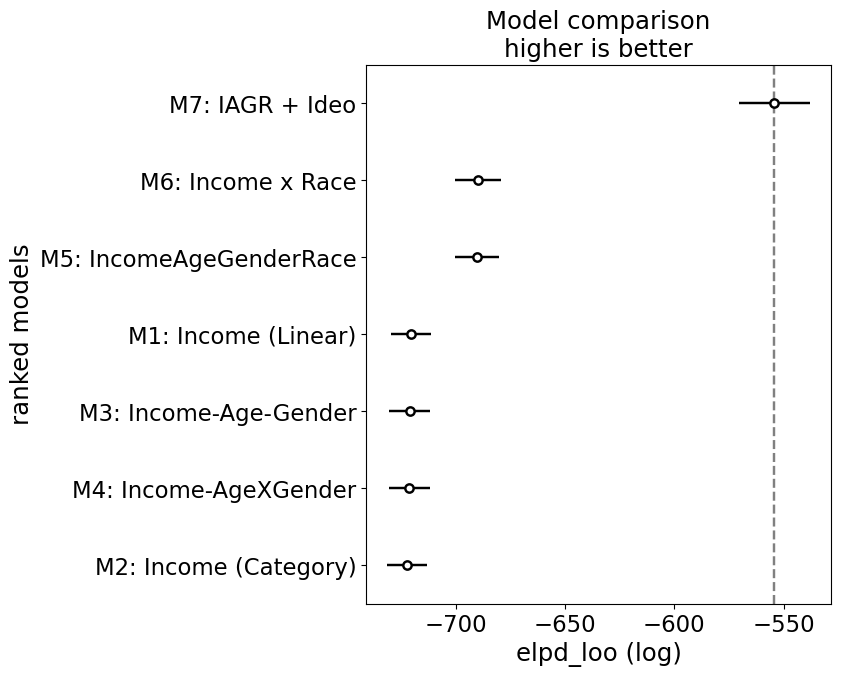

In [74]:
nes_models['M7: IAGR + Ideo'] = model7_fit
nes_compare = arviz.compare(nes_models)
arviz.plot_compare(nes_compare)

In [75]:
model8_ideo = bambi.Model(
    "rvote['1'] ~ real_ideo",
    nes_df,
    family='bernoulli'
)
model8_fit = model8_ideo.fit(idata_kwargs={"log_likelihood": True})
print(
    bg_ros.bambi_markdown(
        model8_fit,
        ['real_ideo',],
    )
)

Modeling the probability that rvote==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, real_ideo]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | nan | nan
Intercept | -4.46 | 0.30
real_ideo | 0.89 | 0.06



<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

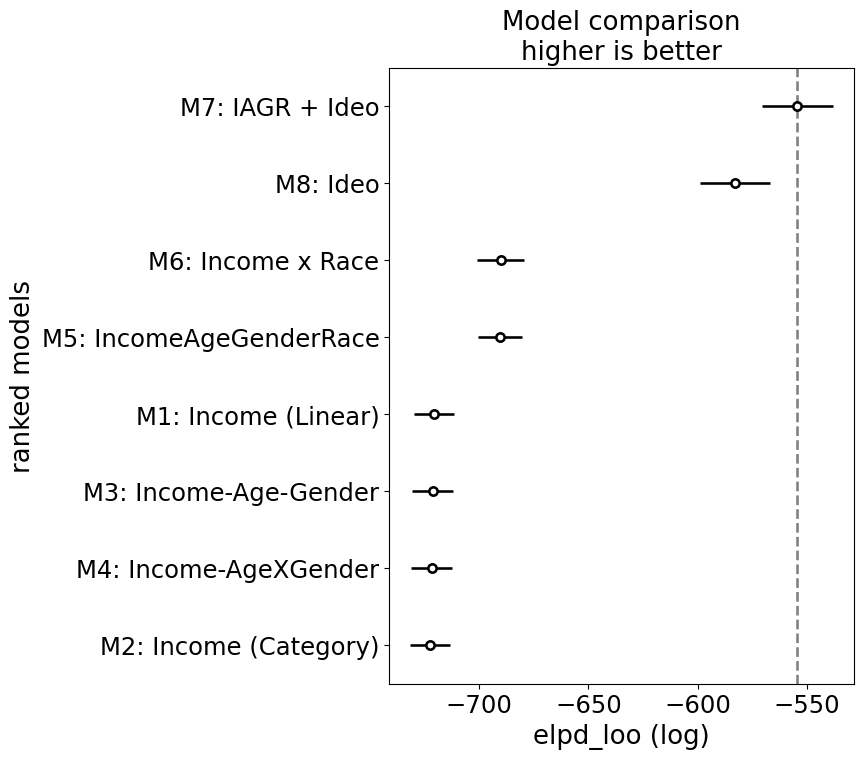

In [24]:
nes_models['M8: Ideo'] = model8_fit
nes_compare = arviz.compare(nes_models)
arviz.plot_compare(nes_compare)

## 13.2, Sketching the logistic curve

> Sketch the following logistic regression curves with pen on paper:
>
> (a) $\text{Pr}(y = 1) = \text{logit}^{-1}(x)$
> 
> (b) $\text{Pr}(y = 1) = \text{logit}^{-1}(2 + x)$
> 
> (c) $\text{Pr}(y = 1) = \text{logit}^{-1}(2x)$
> 
> (d) $\text{Pr}(y = 1) = \text{logit}^{-1}(2 + 2x)$
> 
> (e) $\text{Pr}(y = 1) = \text{logit}^{-1}(-2x)$

In [25]:
xmax = 3
xs = numpy.arange(-1 * xmax, xmax + 0.1, 0.1)

y_a = special.expit(xs)
y_b = special.expit(xs + 2)
y_c = special.expit(2 * xs)
y_d = special.expit(2 * xs + 2)
y_e = special.expit(-2 * xs)

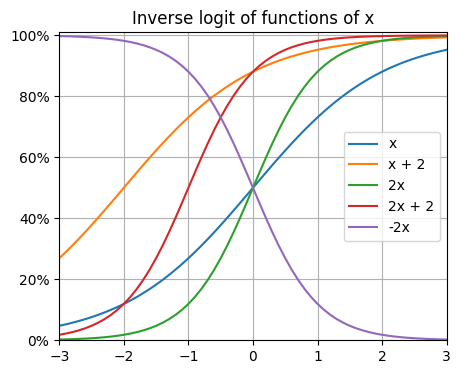

In [26]:
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
ax.plot(xs, y_a, label='x')
ax.plot(xs, y_b, label='x + 2')
ax.plot(xs, y_c, label='2x')
ax.plot(xs, y_d, label='2x + 2')
ax.plot(xs, y_e, label='-2x')
ax.set_ylim(0, 1.01)
ax.set_yticks(
    [0, 0.2, 0.4, 0.6, 0.8, 1],
    [f'{int(100 * yi)}%' for yi in [0, 0.2, 0.4, 0.6, 0.8, 1]],
)
ax.set_xlim(-1 * xmax, xmax)
ax.set_title('Inverse logit of functions of x')
ax.legend()
ax.grid()
ax.set_axisbelow(True)

## 13.3, Understanding logistic regression coefficients

> In Chapter 7 we fit a model predicting incumbent party’s two-party vote
> percentage given economic growth: vote = 46.2 + 3.1 * growth + error, where
> growth ranges from -0.5 to 4.5 in the data, and errors are approximately
> normally distributed with mean 0 and standard deviation 3.8. Suppose instead
> we were to fit a logistic regression,
> $\text{Pr}(\text{vote} > 50) = \text{logit}^{-1}(a + b \times \text{growth})$.
> Approximately what are the estimates of $(a, b)$?
>
> Figure this out in four steps:
>
> (i) use the fitted linear regression model to estimate Pr(vote > 50) for
>     different values of growth;
>
> (ii) second, plot these probabilities and draw a logistic curve through them;
>
> (iii) use the divide-by-4 rule to estimate the slope of the logistic
>    regression model;
>
> (iv) use the point where the probability goes through 0.5 to deduce the
>     intercept.
>
> Do all this using the above information, without downloading the data and
> fitting the model.

In [27]:
growths = numpy.arange(-0.5, 4.5 + 0.02, 0.02)
vote_shares = [46.2 + 3.1 * gi for gi in growths]
win_probs = [stats.norm.sf(50, loc=vsi, scale=3.8)
             for vsi in vote_shares]

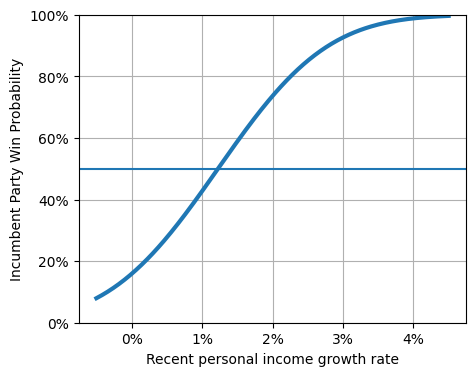

In [28]:
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
ax.plot(growths, win_probs, linewidth=3)
ax.grid()
ax.set_xticks(
    range(5),
    [str(i) + '%' for i in range(5)],
)
ax.set_xlabel('Recent personal income growth rate')
ax.set_ylim(0, 1)
yt = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
ax.set_yticks(
    yt,
    [str(int(100 * yti)) + '%' for yti in yt],
)
ax.set_ylabel('Incumbent Party Win Probability')
ax.axhline(0.5)
ax.set_axisbelow(True)

In [29]:
special.expit(-1.82)  # Predicted win prob. when growth is zero

np.float64(0.13943387296165005)

## 13.4, Logistic regression with two predictors

> The following logistic regression has been fit:

```
            Median MAD_SD
(Intercept) -1.9    0.6
x            0.7    0.8
z            0.7    0.5
```

> Here, $x$ is a continuous predictor ranging from 0 to 10, and $z$ is a binary
> predictor taking on the values 0 and 1. Display the fitted model as two curves
> on a graph of $\text{Pr}(y = 1)$ vs. $x$.

In [30]:
xs = numpy.arange(0, 10.01, 0.05)
p0 = special.expit(-1.9 + 0.7 * xs)
p1 = special.expit(-1.2 + 0.7 * xs)

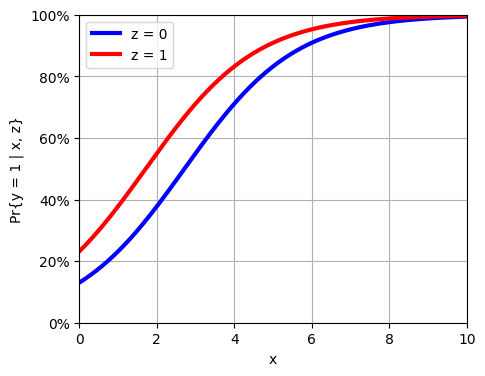

In [31]:
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
ax.plot(xs, p0, 'b-', label='z = 0', linewidth=3)
ax.plot(xs, p1, 'r-', label='z = 1', linewidth=3)
ax.set_xlabel('x')
ax.set_ylabel('Pr{y = 1 | x, z}')
ax.set_ylim(bottom=0)
ax.set_xlim(0, 10)
ax.grid()
ax.set_axisbelow(True)
ax.set_ylim(0, 1)
ax.set_yticks(
    numpy.arange(0, 1.1, 0.2),
    [f'{int(100 * yi)}%' for yi in numpy.arange(0, 1.1, 0.2)],
)
ax.legend()

## 13.5, Interpreting logistic regression coefficients

> Here is a fitted model from the Bangladesh analysis predicting whether a
> person with high-arsenic drinking water will switch wells, given the arsenic
> level in their existing well and the distance to the nearest safe well:

```
stan_glm(formula = switch ~ dist100 + arsenic, family=binomial(link="logit"), data=wells)
             Median MAD_SD
(Intercept)   0.00   0.08
dist100      -0.90   0.10
arsenic       0.46   0.04
```

> Compare two people who live the same distance from the nearest well but whose
> arsenic levels differ, with one person having an arsenic level of 0.5 and the
> other person having a level of 1.0. You will estimate how much more likely
> this second person is to switch wells. Give an approximate estimate, standard
> error, 50% interval, and 95% interval, using two different methods:
>
> (a) Use the divide-by-4 rule, based on the information from this regression
>     output.
>
> (b) Use predictive simulation from the fitted model in R, under the assumption
>     that these two people each live 50 meters from the nearest safe well.

In [32]:
wells_df = pandas.read_csv('/home/bgawalt/ros/datasets/wells.csv')

In [33]:
wells_model = bambi.Model("switch['1'] ~ dist100 + arsenic", wells_df, family="bernoulli")
wells_fit = wells_model.fit()
print(bg_ros.bambi_markdown(wells_fit, ["dist100", "arsenic"]))

Modeling the probability that switch==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dist100, arsenic]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | nan | nan
Intercept | 0.00 | 0.08
dist100   | -0.90 | 0.10
arsenic   | 0.46 | 0.04



In [34]:
diffs = []
for chain in range(4):
    sims = wells_fit.posterior.sel(chain=chain).to_dataframe()
    for _, row in sims.iterrows():
        a = row["Intercept"] + 0.5 * row["dist100"]
        b = row["arsenic"]
        prob_lo = special.expit(a + b * 0.5 + stats.logistic.rvs())
        prob_hi = special.expit(a + b + stats.logistic.rvs())
        diffs.append(100 * (prob_hi - prob_lo))

In [35]:
print('*  Mean diff:', f'{numpy.mean(diffs):0.1f}', '%')
print('*  Std. dev diff:', f'{numpy.std(diffs):0.1f}', '%')
qs = [0.025, 0.25, 0.75, 0.975]
diff_qs = numpy.quantile(diffs, qs)
print('*  50% range:', f'[{diff_qs[1]:0.1f}, {diff_qs[2]:0.1f}]')
print('*  95% range:', f'[{diff_qs[0]:0.1f}, {diff_qs[3]:0.1f}]')
    

*  Mean diff: 3.6 %
*  Std. dev diff: 40.5 %
*  50% range: [-24.9, 33.4]
*  95% range: [-75.6, 78.2]


Text(0.5, 0, 'Pct. Point Diff (High As - Low As)')

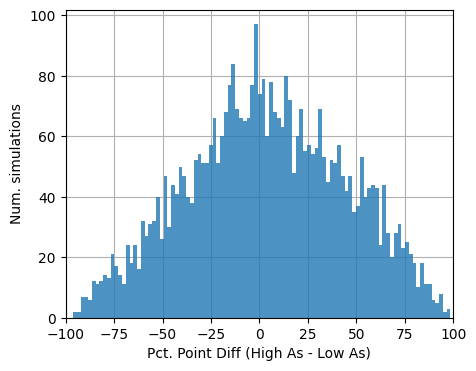

In [36]:
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
ax.hist(diffs, bins=100, alpha=0.8)
ax.grid()
ax.set_axisbelow(True)
ax.set_xlim(-100, 100)
ax.set_ylabel('Num. simulations')
ax.set_xlabel('Pct. Point Diff (High As - Low As)')

In [37]:
numpy.sqrt(0.08 ** 2 + 0.1 ** 2)

np.float64(0.12806248474865697)

## 13.7, Graphing a fitted logistic regression

> We downloaded data with weight (in pounds) and age (in years) from a random
> sample of American adults. We then defined a new variable:

`heavy <- weight > 200`

> and fit a logistic regression, predicting heavy from height (in inches):

```
stan_glm(formula = heavy ~ height, family=binomial(link="logit"), data=health)

              Median MAD_SD
(Intercept)  -21.51   1.60
height         0.28   0.02
```

> (a) Graph the logistic regression curve (the probability that someone is
>     heavy) over the approximate range of the data. Be clear where the line
>     goes through the 50% probability point.
>
> (b) Fill in the blank: near the 50% point, comparing two people who differ by
>     one inch in height, you’ll expect a difference of __ in the probability of
>     being heavy.

In [38]:
# Range of heights: 5'0" to 6'6", by quarter inches
heights = numpy.arange(5 * 12, 6 * 12 + 7, 0.25)
heavies = special.expit(-21.51 + 0.28 * heights)

In [39]:
# We cross the 50% line when a + bx = 0
height50 = 21.51 / 0.28
print(f'{height50:0.1f} inches')

76.8 inches


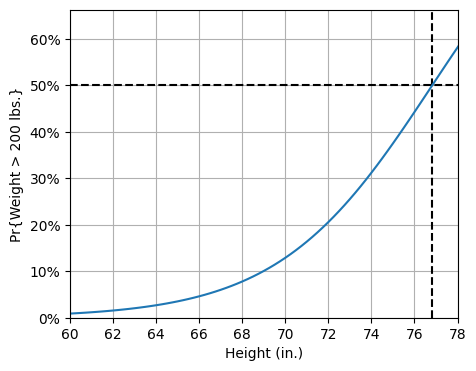

In [40]:
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
ax.axvline(height50, color='k', linestyle='--')
ax.axhline(0.5, color='k', linestyle='--')
ax.plot(heights, heavies)
ax.set_xlabel('Height (in.)')
ax.set_ylabel('Pr{Weight > 200 lbs.}')
ax.set_ylim(bottom=0)
ax.set_xlim(60, 78)
ax.set_yticks(
    [0.1 * yi for yi in range(7)],
    [f'{10 * yi}%' for yi in range(7)],
)
ax.grid()
ax.set_axisbelow(True)

## 13.9, The algebra of logistic regression with one predictor

> You are interested in how well the combined earnings of the parents in a
> child’s family predicts high school graduation. You are told that the
> probability a child graduates from high school is 27% for children whose
> parents earn no income and is 88% for children whose parents earn 60,000
> dollars.  Determine the logistic regression model that is consistent with this
> information. For simplicity, you may want to assume that income is measured in
> units of 10,000.

In [41]:
a = special.logit(0.27)
b = (special.logit(0.88) - special.logit(0.27)) / 6
print(f'(a, b) = ({a:0.2f}, {b:0.2f})')

(a, b) = (-0.99, 0.50)


## 13.10, Expressing a comparison of proportions as a logistic regression

> A randomized experiment is performed within a survey, and 1000 people are
> contacted. Half the people contacted are promised a $5 incentive to
> participate, and half are not promised an incentive. The result is a 50%
> response rate among the treated group and 40% response rate among the control
> group.
> 
> (a) Set up these results as data in R. From these data, fit a logistic
>     regression of response on the treatment indicator.
> 
> (b) Compare to the results from Exercise 4.1.

In [42]:
prop_df = pandas.DataFrame(data={
    'incentivized': ([0,] * 500) + ([1,] * 500),
    'responded': ([1,] * 200) + ([0,] * 300) + ([1,] * 250) + ([0,] * 250)
})

In [43]:
prop_model = bambi.Model("responded['1'] ~ incentivized", prop_df, family="bernoulli")
prop_fit = prop_model.fit()
arviz.summary(prop_fit)

Modeling the probability that responded==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, incentivized]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-0.403,0.093,-0.575,-0.224,0.001,0.001,3925.0,3023.0,1.0
incentivized,0.404,0.129,0.160,0.647,0.002,0.002,3992.0,2529.0,1.0


In [44]:
print(bg_ros.bambi_markdown(prop_fit, ['incentivized',]))

Coef.        | Mean   | s.e.
------------ | ------ | ------
sigma        | nan | nan
Intercept    | -0.40 | 0.09
incentivized | 0.40 | 0.13



## 13.11, Building a logistic regression model

> The folder Rodents contains data on rodents in a sample of New York City
> apartments.
>
> (a) Build a logistic regression model to predict the presence of rodents (the
>     variable `rodent2` in the dataset) given indicators for the ethnic groups
>     (race). Combine categories as appropriate. Discuss the estimated
>     coefficients in the model.
>
> (b) Add to your model some other potentially relevant predictors describing
>     the apartment, building, and community district. Build your model using
>     the general principles explained in Section 12.6. Discuss the coefficients
>     for the ethnicity indicators in your model.

In [35]:
rodents_dat = bg_ros.DATFileParser('/home/bgawalt/ros/datasets/rodents.dat')
for i, field in enumerate(sorted(rodents_dat.fields)):
    print(field, end=',  ')
    if i % 5 == 4:
        print('')

black_Mean,  bldg,  board2,  board2_Mean,  borough,  
cd,  dilap,  dilap_Mean,  duration,  duration_Mean,  
extflr5_2,  extflr5_2_Mean,  extwin4_2,  extwin4_2_Mean,  foreign,  
foreign_Mean,  help,  help_Mean,  hispanic_Mean,  housewgt,  
housing,  intcrack2,  intcrack2_Mean,  inthole2,  inthole2_Mean,  
intleak2,  intleak2_Mean,  intpeel_cat,  numunits,  old,  
old_Mean,  ownhous_Mean,  personrm,  poverty,  poverty_Mean,  
povertyx2,  povertyx2_Mean,  pubhous_Mean,  race,  regext,  
regext_Mean,  rodent2,  sequenceno,  stories,  struct,  
struct_Mean,  subsidy,  totincom2,  under6,  unitflr2,  
vacrate,  

In [24]:
rodents_df, na_counts = rodents_dat.parse(['rodent2', 'race'], [])
for k, v in na_counts.items():
    print(k, v)
rodents_df.describe()
c = {}
for r in rodents_df["race"]:
    c[r] = c.get(r, 0) + 1
for k in range(1, 8):
    print(k, ':', c[k])
print(bg_ros.dataframe_describe_markdown(rodents_df))

rodent2 197
1 : 633
2 : 404
3 : 139
4 : 223
5 : 139
6 : 6
7 : 7
|         | rodent2 | race
--------- | ------- | ----
**count** | 1551.00 | 1551.00
**mean**  | 0.24 | 2.28
**std**   | 0.43 | 1.41
**min**   | 0.00 | 1.00
**25%**   | 0.00 | 1.00
**50%**   | 0.00 | 2.00
**75%**   | 0.00 | 3.00
**max**   | 1.00 | 7.00



In [26]:
rodents_dat = bg_ros.DATFileParser('/home/bgawalt/ros/datasets/rodents.dat')
rodents_dat.add_int_filter('race', lambda r: r <=5)
rodents_df, na_counts = rodents_dat.parse(['rodent2', 'race'], [])
for k, v in na_counts.items():
    print(k, v)
rodents_df.describe()
c = {}
for r in rodents_df["race"]:
    c[r] = c.get(r, 0) + 1
for k in range(1, 6):
    print(k, ':', c[k])
print(bg_ros.dataframe_describe_markdown(rodents_df))

rodent2 196
1 : 633
2 : 404
3 : 139
4 : 223
5 : 139
|         | rodent2 | race
--------- | ------- | ----
**count** | 1538.00 | 1538.00
**mean**  | 0.24 | 2.24
**std**   | 0.43 | 1.36
**min**   | 0.00 | 1.00
**25%**   | 0.00 | 1.00
**50%**   | 0.00 | 2.00
**75%**   | 0.00 | 3.00
**max**   | 1.00 | 5.00



In [80]:
rodents_dat.add_int_filter('race', lambda r: r <=5)
rodents_df, na_counts = rodents_dat.parse(
    [
        'rodent2', 'race', 'numunits', 'stories', 'extwin4_2',
        'extflr5_2', 'old', 'poverty', 'povertyx2',
    ],
    ['extwin4_2_Mean', 'extflr5_2_Mean', 'old_Mean'],
)
for k, v in na_counts.items():
    print(k, v)
rodents_df.describe()

rodent2 196
extflr5_2 75
extwin4_2 9


,rodent2,race,numunits,stories,extwin4_2,extflr5_2,old,poverty,povertyx2,extwin4_2_Mean,extflr5_2_Mean,old_Mean
count,1454.000000,1454.000000,1454.000000,1454.000000,1454.000000,1454.000000,1454.000000,1454.000000,1454.000000,1454.000000,1454.000000,1454.000000
mean,0.239340,2.251719,7.797111,3.614168,0.028198,0.043329,0.615543,0.211829,0.388583,0.028645,0.044182,0.640557
std,0.426827,1.365657,3.965192,1.994236,0.165595,0.203666,0.486634,0.408745,0.487596,0.024127,0.036060,0.185523
min,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000
25%,0.000000,1.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010000,0.020000,0.502500
50%,0.000000,2.000000,10.000000,4.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.020000,0.030000,0.670000
75%,0.000000,3.000000,11.000000,5.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.040000,0.060000,0.800000
max,1.000000,5.000000,12.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.110000,0.140000,0.960000


In [81]:
print(bg_ros.dataframe_describe_markdown(rodents_df))

|         | rodent2 | race | numunits | stories | extwin4_2 | extflr5_2 | old | poverty | povertyx2 | extwin4_2_Mean | extflr5_2_Mean | old_Mean
--------- | ------- | ---- | -------- | ------- | --------- | --------- | --- | ------- | --------- | -------------- | -------------- | --------
**count** | 1454.00 | 1454.00 | 1454.00 | 1454.00 | 1454.00 | 1454.00 | 1454.00 | 1454.00 | 1454.00 | 1454.00 | 1454.00 | 1454.00
**mean**  | 0.24 | 2.25 | 7.80 | 3.61 | 0.03 | 0.04 | 0.62 | 0.21 | 0.39 | 0.03 | 0.04 | 0.64
**std**   | 0.43 | 1.37 | 3.97 | 1.99 | 0.17 | 0.20 | 0.49 | 0.41 | 0.49 | 0.02 | 0.04 | 0.19
**min**   | 0.00 | 1.00 | 1.00 | 1.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.10
**25%**   | 0.00 | 1.00 | 3.00 | 2.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.01 | 0.02 | 0.50
**50%**   | 0.00 | 2.00 | 10.00 | 4.00 | 0.00 | 0.00 | 1.00 | 0.00 | 0.00 | 0.02 | 0.03 | 0.67
**75%**   | 0.00 | 3.00 | 11.00 | 5.00 | 0.00 | 0.00 | 1.00 | 0.00 | 1.00 | 0.04 | 0.06 | 0.80
**max**   | 1.

In [82]:
model_r1_race = bambi.Model("rodent2['1'] ~ C(race)", rodents_df, family='bernoulli')
model_r1_fit = model_r1_race.fit(idata_kwargs={"log_likelihood": True})
print(
    bg_ros.bambi_markdown(
        model_r1_fit,
        [f'C(race)[{i}]' for i in range(2, 6)],
    ),
)

Modeling the probability that rodent2==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, C(race)]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


Coef.      | Mean   | s.e.
---------- | ------ | ------
sigma      | nan | nan
Intercept  | -2.12 | 0.13
C(race)[2] | 1.31 | 0.17
C(race)[3] | 1.53 | 0.21
C(race)[4] | 1.88 | 0.19
C(race)[5] | 0.70 | 0.25



In [83]:
for f in ['extwin4_2_Mean', 'extflr5_2_Mean', 'old_Mean']:
    mu = numpy.mean(rodents_df[f])
    sig = numpy.std(rodents_df[f])
    rodents_df[f + "_z"] = (rodents_df[f] - mu) / sig

In [84]:
model_r2_linear = bambi.Model(
    "rodent2['1'] ~ C(race) + numunits + stories + old + extwin4_2_Mean_z + extflr5_2_Mean_z + old_Mean_z",
    rodents_df,
    family='bernoulli'
)
model_r2_fit = model_r2_linear.fit(idata_kwargs={"log_likelihood": True})
print(
    bg_ros.bambi_markdown(
        model_r2_fit,
        [f'C(race)[{i}]' for i in range(2, 6)] + 
        ['numunits', 'stories', 'old', 'extwin4_2_Mean_z', 'extflr5_2_Mean_z', 'old_Mean_z'],
    ),
)

Modeling the probability that rodent2==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, C(race), numunits, stories, old, extwin4_2_Mean_z, extflr5_2_Mean_z, old_Mean_z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


Coef.            | Mean   | s.e.
---------------- | ------ | ------
sigma            | nan | nan
Intercept        | -3.75 | 0.29
C(race)[2]       | 1.30 | 0.18
C(race)[3]       | 1.32 | 0.23
C(race)[4]       | 1.53 | 0.20
C(race)[5]       | 0.78 | 0.26
numunits         | 0.26 | 0.04
stories          | -0.29 | 0.09
old              | 0.88 | 0.17
extwin4_2_Mean_z | -0.03 | 0.09
extflr5_2_Mean_z | 0.18 | 0.09
old_Mean_z       | 0.10 | 0.09



<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

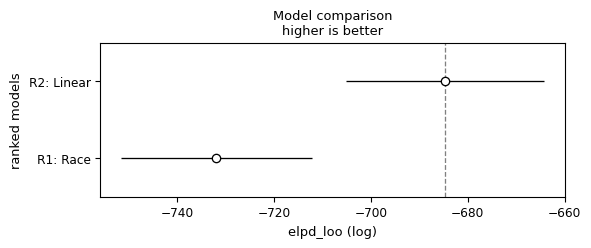

In [85]:
rodent_models = {
    'R1: Race': model_r1_fit,
    'R2: Linear': model_r2_fit,
}
arviz.plot_compare(arviz.compare(rodent_models))

In [86]:
model_r3_cats = bambi.Model(
    "rodent2['1'] ~ C(race) + C(numunits) + C(stories) + old + extwin4_2_Mean_z + extflr5_2_Mean_z + old_Mean_z",
    rodents_df,
    family='bernoulli'
)
model_r3_fit = model_r3_cats.fit(idata_kwargs={"log_likelihood": True})
print(
    bg_ros.bambi_markdown(
        model_r3_fit,
        [f'C(race)[{i}]' for i in range(2, 6)] + 
        [f'C(numunits)[{i}]' for i in range(2, 13)] + 
        [f'C(stories)[{i}]' for i in range(2, 8)] + 
        ['old', 'extwin4_2_Mean_z', 'extflr5_2_Mean_z', 'old_Mean_z'],
    ),
)

Modeling the probability that rodent2==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, C(race), C(numunits), C(stories), old, extwin4_2_Mean_z, extflr5_2_Mean_z, old_Mean_z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


Coef.            | Mean   | s.e.
---------------- | ------ | ------
sigma            | nan | nan
Intercept        | -3.60 | 0.32
C(race)[2]       | 1.25 | 0.19
C(race)[3]       | 1.28 | 0.23
C(race)[4]       | 1.47 | 0.20
C(race)[5]       | 0.82 | 0.26
C(numunits)[2]   | 0.23 | 0.78
C(numunits)[3]   | 0.43 | 0.30
C(numunits)[4]   | 0.52 | 0.71
C(numunits)[5]   | 0.08 | 0.35
C(numunits)[6]   | 0.47 | 0.40
C(numunits)[7]   | 0.28 | 0.35
C(numunits)[8]   | -0.53 | 0.53
C(numunits)[9]   | 1.13 | 0.40
C(numunits)[10]  | 0.94 | 0.31
C(numunits)[11]  | 0.89 | 0.33
C(numunits)[12]  | 0.99 | 0.36
C(stories)[2]    | 0.88 | 0.27
C(stories)[3]    | 0.70 | 0.31
C(stories)[4]    | 1.30 | 0.32
C(stories)[5]    | 0.56 | 0.32
C(stories)[6]    | 0.09 | 0.36
C(stories)[7]    | -0.95 | 0.52
old              | 0.57 | 0.18
extwin4_2_Mean_z | -0.02 | 0.09
extflr5_2_Mean_z | 0.17 | 0.09
old_Mean_z       | 0.09 | 0.09



<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

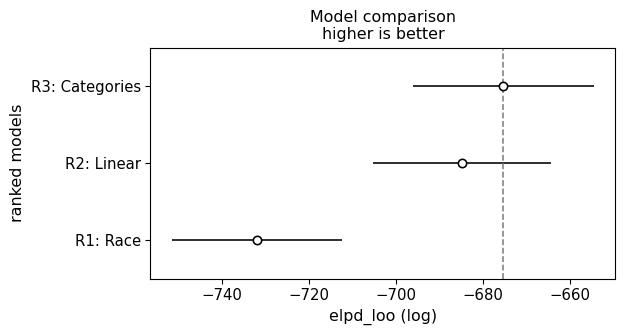

In [87]:
rodent_models['R3: Categories'] = model_r3_fit
arviz.plot_compare(arviz.compare(rodent_models))

Modeling the probability that rodent2==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, C(race), numunits, stories, old, extwin4_2_Mean_z, extflr5_2_Mean_z, old_Mean_z, C(race):numunits, C(race):stories, C(race):old]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 10 seconds.


Coef.               | Mean   | s.e.
------------------- | ------ | ------
sigma               | nan | nan
Intercept           | -3.33 | 0.37
C(race)[2]          | 0.65 | 0.50
C(race)[3]          | 0.41 | 0.69
C(race)[4]          | 1.32 | 0.57
C(race)[5]          | -0.81 | 0.68
C(race):numunits[2] | 0.07 | 0.08
C(race):numunits[3] | 0.12 | 0.12
C(race):numunits[4] | -0.01 | 0.10
C(race):numunits[5] | 0.11 | 0.11
C(race):stories[2]  | 0.09 | 0.17
C(race):stories[3]  | -0.01 | 0.23
C(race):stories[4]  | 0.12 | 0.19
C(race):stories[5]  | 0.10 | 0.23
numunits            | 0.22 | 0.06
stories             | -0.34 | 0.12
old                 | 0.99 | 0.30
extwin4_2_Mean_z    | -0.05 | 0.09
extflr5_2_Mean_z    | 0.18 | 0.09
old_Mean_z          | 0.10 | 0.09



<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

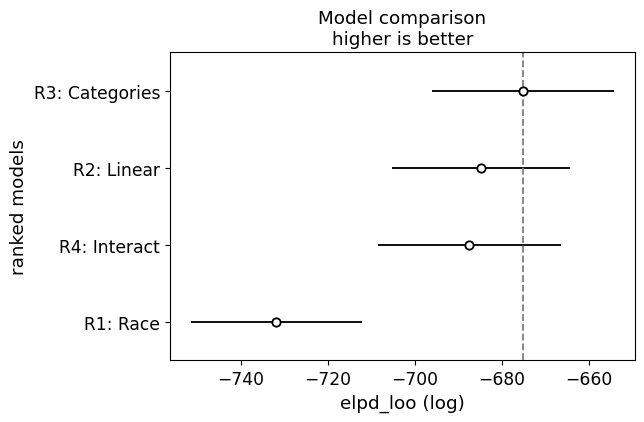

In [88]:
model_r4_inter = bambi.Model(
    (
        "rodent2['1'] ~ C(race) + numunits + stories + old + " +
        "extwin4_2_Mean_z + extflr5_2_Mean_z + old_Mean_z + " +
        "C(race):numunits + C(race):stories + C(race):old"
    ),
    rodents_df,
    family='bernoulli'
)
model_r4_fit = model_r4_inter.fit(idata_kwargs={"log_likelihood": True})
print(
    bg_ros.bambi_markdown(
        model_r4_fit,
        [f'C(race)[{i}]' for i in range(2, 6)] + 
        [f'C(race):numunits[{i}]' for i in range(2, 6)] + 
        [f'C(race):stories[{i}]' for i in range(2, 6)] + 
        ['numunits', 'stories', 'old', 'extwin4_2_Mean_z', 'extflr5_2_Mean_z', 'old_Mean_z'],
    ),
)
rodent_models['R4: Interact'] = model_r4_fit
arviz.plot_compare(arviz.compare(rodent_models))

Modeling the probability that rodent2==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, C(race), numunits, stories, old, extwin4_2_Mean_z, extflr5_2_Mean_z, old_Mean_z, poverty, povertyx2]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


Coef.            | Mean   | s.e.
---------------- | ------ | ------
sigma            | nan | nan
Intercept        | -3.78 | 0.29
C(race)[2]       | 1.27 | 0.19
C(race)[3]       | 1.26 | 0.24
C(race)[4]       | 1.49 | 0.20
C(race)[5]       | 0.74 | 0.26
numunits         | 0.26 | 0.05
stories          | -0.29 | 0.09
old              | 0.88 | 0.17
extwin4_2_Mean_z | -0.04 | 0.08
extflr5_2_Mean_z | 0.17 | 0.09
old_Mean_z       | 0.09 | 0.09
poverty          | -0.07 | 0.20
povertyx2        | 0.18 | 0.18



<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

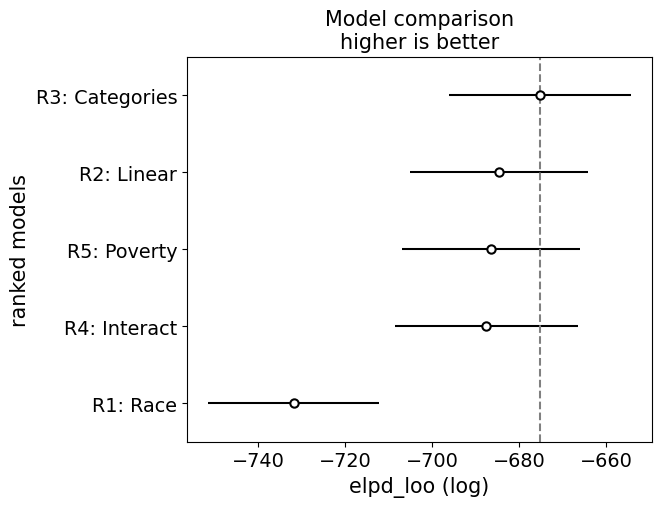

In [93]:
model_r5_poverty = bambi.Model(
    (
        "rodent2['1'] ~ C(race) + numunits + stories + old + " +
        "extwin4_2_Mean_z + extflr5_2_Mean_z + old_Mean_z + " +
        "poverty + povertyx2"
    ),
    rodents_df,
    family='bernoulli'
)
model_r5_fit = model_r5_poverty.fit(idata_kwargs={"log_likelihood": True})
print(
    bg_ros.bambi_markdown(
        model_r5_fit,
        [f'C(race)[{i}]' for i in range(2, 6)] + 
        ['numunits', 'stories', 'old', 'extwin4_2_Mean_z', 'extflr5_2_Mean_z', 'old_Mean_z'] +
        ['poverty', 'povertyx2'],
    ),
)
rodent_models['R5: Poverty'] = model_r5_fit
arviz.plot_compare(arviz.compare(rodent_models))

## 13.12, Fake-data simulation to evaluate a statistical procedure

> When can we get away with fitting linear regression to binary data? You will
> explore this question by simulating data from a logistic regression,
> then fitting a linear regression, then looping this procedure to compute the
> coverage of the estimates.
>
> (a) You will be simulating independent binary data, $y_i; i = 1, \ldots, n$,
>     from the model,
>     $\text{Pr}(y_i = 1) = \text{logit}^{-1}(a + bx_i + \theta z_i)$, where the
>     $x_i$’s are drawn uniformly from the range (0, 100) and the $z_i$’s are
>     randomly set to 0 or 1. The “cover story” here is that $y$ represents
>     passing or failing an exam, $x$ is the score on a pre-test, and $z$ is a
>     treatment.  To do this simulation, you will need to set true values of
>     $a$, $b$, and $\theta$. Choose $a$ and $b$ so that 60% of the students in
>     the control group will pass the exam, with the probability of passing
>     being 80% for students in the control group who scored 100 on the midterm.
>     Choose $\theta$ so that the average probability of passing increases by 10
>     percentage points under the treatment. Report your values for $a$, $b$,
>     $\theta$ and explain your reasoning (including simulation code). It’s
>     not enough just to guess.
> 
> (b) Simulate $n = 50$ data points from your model, and then fit a linear
>     regression of $y$ on $x$ and $z$. Look at the estimate and standard error
>     for the coefficient of $z$. Does the true average treatment effect fall
>     inside this interval?
>
> (c) Repeat your simulation in (b) 10,000 times. Compute the coverage of the
>     normal-theory 50% and 95% intervals (that is, the estimates $\pm0.67$ and
>     1.96 standard errors).

In [ ]:
b = (special.logit(0.8) - special.logit(0.6)) / 50
a = 2 * special.logit(0.6) - special.logit(0.8)
theta = special.logit(0.7) - special.logit(0.6)

In [ ]:
print(f'(a={a:0.2f}, b={b:0.2f}, theta={theta:0.2f})')

In [ ]:
n = 50
def fake_dataset() -> pandas.DataFrame:
    """Returns dataframe with columns ('x', 'z', 'y') per question spec."""
    xs = stats.uniform.rvs(scale=100, size=n)
    zs = stats.bernoulli.rvs(0.5, size=n)
    latents = special.expit(a + b * xs + theta * zs)
    unifs = stats.uniform.rvs(size=n)
    ys = [1 if li > ui else 0 for (li, ui) in zip(latents, unifs)]
    return pandas.DataFrame(data={'x': xs, 'z': zs, 'y': ys})

In [ ]:
fake_df = fake_dataset()
fake_model = bambi.Model("y['1'] ~ x + z", fake_df, family="bernoulli")
fake_fit = fake_model.fit()
arviz.summary(fake_fit)

In [ ]:
print(bg_ros.bambi_markdown(fake_fit, ['x', 'z']))

In [ ]:
num_sims = 15
estimates = []
ses = []
for _ in range(num_sims):
    fake_df = fake_dataset()
    fake_model = bambi.Model("y['1'] ~ x + z", fake_df, family="bernoulli")
    fake_fit = fake_model.fit(quiet=True)
    summ = arviz.summary(fake_fit)
    estimates.append(summ['mean']['z'])
    ses.append(summ['sd']['z'])

In [ ]:
fig = pyplot.figure(figsize=(10, 3))
ax = fig.gca()
ax.plot(range(num_sims), estimates, 'b.', markersize=7, label='Mean estimate')
for i, (mu, se) in enumerate(zip(estimates, ses)):
    label50 = None
    label95 = None
    if i == 0:
        label50 = '50% coverage'
        label95 = '95% coverage'
    ax.plot([i, i], [mu - 0.67 * se, mu + 0.67 * se], 'b-', linewidth=3, label=label50)
    ax.plot([i, i], [mu - 1.96 * se, mu + 1.96 * se], 'b-', linewidth=1, label=label95)
ax.grid()
ax.axhline(theta, linestyle='-', color='m', label='True value')
ax.set_axisbelow(True)
ax.set_xlim(-1, num_sims)
ax.set_ylabel('Estimate of theta')
ax.set_xlabel('Simulation round')

ax.legend(ncol=4)
    
    

In [ ]:
cover50 = 0
cover95 = 0
for mu, se in zip(estimates, ses):
    dev = abs(mu - 0.44)
    if dev < 0.67 * se:
        cover50 += 1
    if dev < 1.96 * se:
        cover95 += 1
print(f'Cover 50: {int(float(100 * cover50) / len(ses))}' + '%')
print(f'Cover 95: {int(float(100 * cover95) / len(ses))}' + '%')